Импорт библиотек

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

# Настройка графиков
sns.set_theme(style="whitegrid")
%matplotlib inline

Загрузка датасета, удаление id и отделение целевой перемен

In [16]:
file_path = 'road_accident/train.csv'

df = pd.read_csv(file_path)
    
 # Удаление незначимых признаков (например, id)
features_to_drop = ['id']
df = df.drop(columns=features_to_drop)
    
X = df.drop(columns=['accident_risk'])
y = df['accident_risk']
    

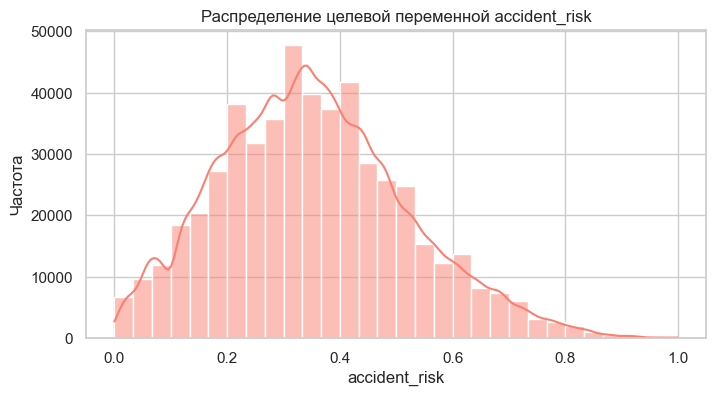

In [17]:
# Анализ дисбаланса целевой переменной
plt.figure(figsize=(8, 4))
sns.histplot(y, kde=True, bins=30, color='salmon')
plt.title('Распределение целевой переменной accident_risk')
plt.xlabel('accident_risk')
plt.ylabel('Частота')
plt.show()

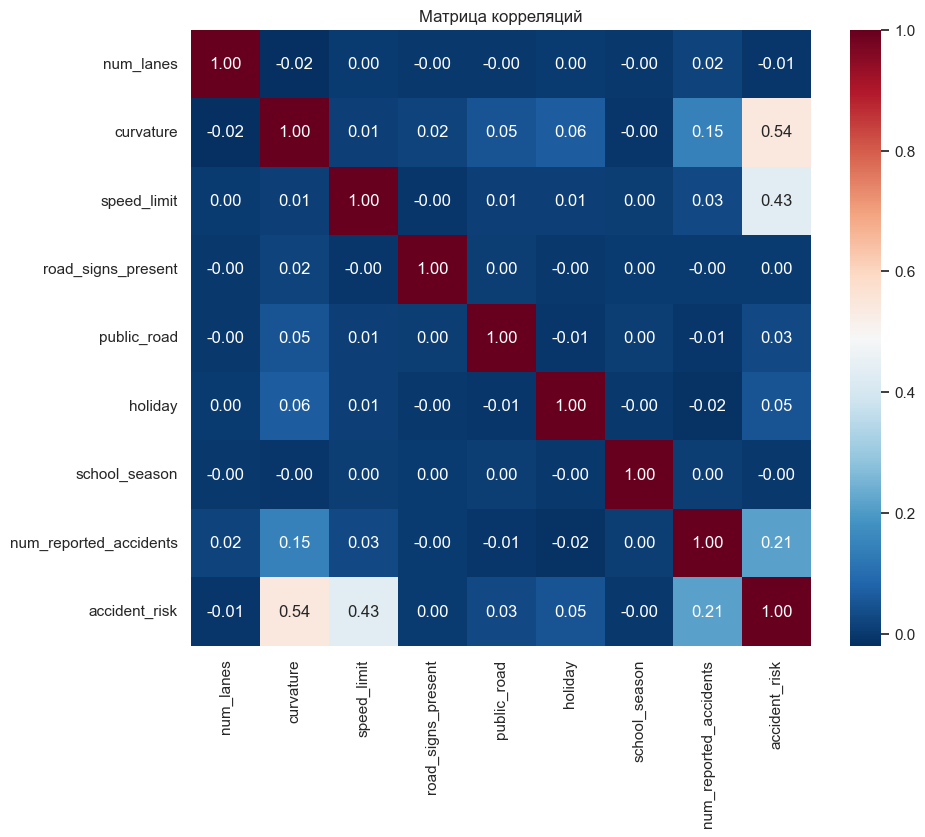

In [18]:
# Матрица корреляций
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu_r', fmt=".2f")
plt.title('Матрица корреляций')
plt.show()

In [21]:
# Группировка признаков для препроцессинга
numeric_features = ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']
categorical_features = ['road_type', 'lighting', 'weather', 'time_of_day']
binary_features = ['road_signs_present', 'public_road', 'holiday', 'school_season']

# Создание трансформера колонок
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('bin', 'passthrough', binary_features)
])

# Инициализация пайплайна с регрессором случайного леса
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=150,max_depth=6, random_state=42, n_jobs=-1))
])

# Разделение выборки на обучающую и тестовую (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [24]:
# Подробный отчет по метрикам
print(f"MAE (Средняя абсолютная ошибка): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE (Среднеквадратичная ошибка): {mean_squared_error(y_test, y_pred):.4f}")
print(f"R^2 Score (Коэффициент детерминации): {r2_score(y_test, y_pred):.4f}")

# Извлечение важности признаков после кодирования
ohe = model.named_steps['preprocessor'].named_transformers_['cat']
ohe_names = ohe.get_feature_names_out(categorical_features)
feature_names = numeric_features + list(ohe_names) + binary_features

importances = model.named_steps['regressor'].feature_importances_
feature_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

MAE (Средняя абсолютная ошибка): 0.0452
MSE (Среднеквадратичная ошибка): 0.0034
R^2 Score (Коэффициент детерминации): 0.8773


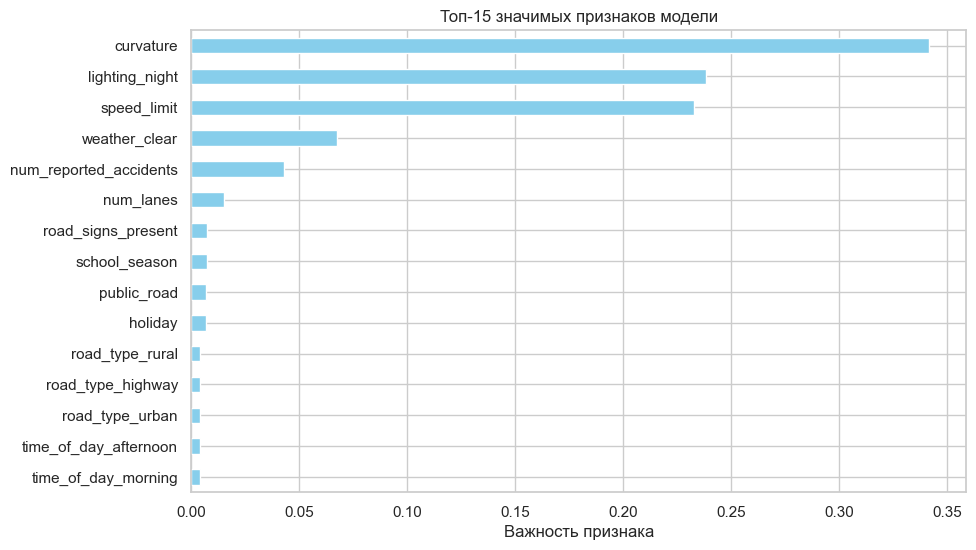

In [ ]:
# Визуализация важности признаков
plt.figure(figsize=(10, 6))
feature_imp.head(15).plot(kind='barh', color='skyblue')
plt.title('Топ-15 значимых признаков модели')
plt.xlabel('Важность признака')
plt.gca().invert_yaxis()
plt.show()

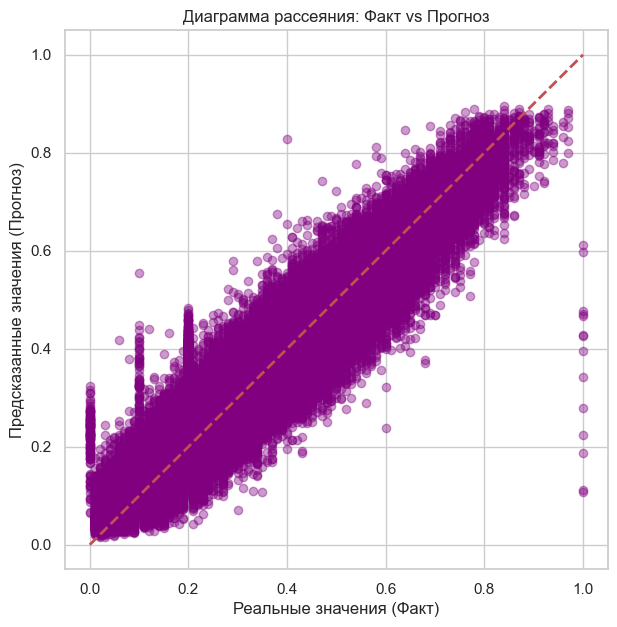

In [ ]:
# График Факт vs Прогноз
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.4, color='purple')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Реальные значения (Факт)')
plt.ylabel('Предсказанные значения (Прогноз)')
plt.title('Диаграмма рассеяния: Факт vs Прогноз')
plt.show()